# 01 — Análise Exploratória do Dataset
**Classificação de Lesões Cutâneas em Imagens Infravermelhas — TCC UFU 2026**

Este notebook realiza a **Etapa 2** do método proposto: inspeção da base TR_heatSkin quanto à estrutura de arquivos, distribuição de classes, quantidade de pacientes e frames, dimensões das imagens e estatísticas de pixel. Os resultados orientam as decisões de pré-processamento e split.

## 1. Imports e configuração

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATASET_ROOT = Path('../data/raw/TR_heatSkin')
CLASSES = ['Healthy', 'Sick']

assert DATASET_ROOT.exists(), f'Dataset não encontrado em {DATASET_ROOT}'
print('Dataset encontrado:', DATASET_ROOT)

Dataset encontrado: ../data/raw/TR_heatSkin


## 2. Estrutura do dataset

In [12]:
records = []

for cls in CLASSES:
    cls_path = DATASET_ROOT / cls
    for patient_dir in sorted(cls_path.iterdir()):
        if not patient_dir.is_dir() or patient_dir.name.startswith('.'):
            continue
        frames = sorted(patient_dir.glob('*.png'))
        records.append({
            'class': cls,
            'patient_id': patient_dir.name,
            'n_frames': len(frames),
            'first_frame': frames[0] if frames else None,
        })

df = pd.DataFrame(records)
print(f'Total de pacientes: {len(df)}')
print()
print(df.groupby('class')['n_frames'].agg(['count', 'sum', 'min', 'max', 'mean']).round(1).rename(columns={
    'count': 'pacientes', 'sum': 'total_frames', 'min': 'min_frames',
    'max': 'max_frames', 'mean': 'média_frames'
}))

Total de pacientes: 180

         pacientes  total_frames  min_frames  max_frames  média_frames
class                                                                 
Healthy        100         59621         217         741         596.2
Sick            80         48927         328         770         611.6


## 3. Distribuição de classes

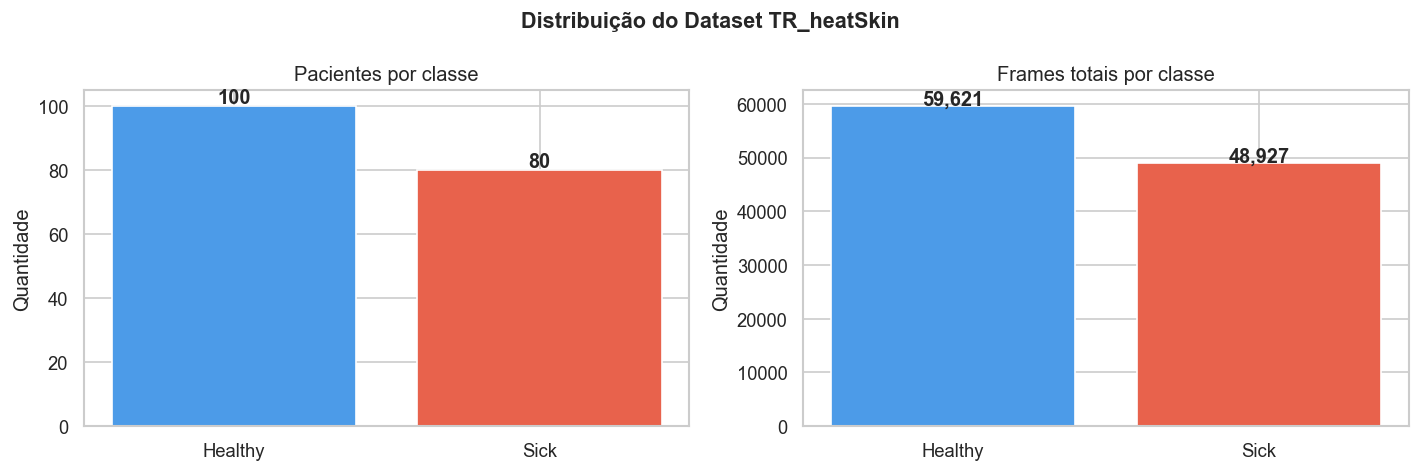

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pacientes por classe
patient_counts = df['class'].value_counts()
axes[0].bar(patient_counts.index, patient_counts.values, color=['#4C9BE8', '#E8624C'])
for i, v in enumerate(patient_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[0].set_title('Pacientes por classe')
axes[0].set_ylabel('Quantidade')

# Frames totais por classe
frame_counts = df.groupby('class')['n_frames'].sum()
axes[1].bar(frame_counts.index, frame_counts.values, color=['#4C9BE8', '#E8624C'])
for i, v in enumerate(frame_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
axes[1].set_title('Frames totais por classe')
axes[1].set_ylabel('Quantidade')

plt.suptitle('Distribuição do Dataset TR_heatSkin', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/class_distribution.png', bbox_inches='tight')
plt.show()

## 4. Distribuição de frames por paciente

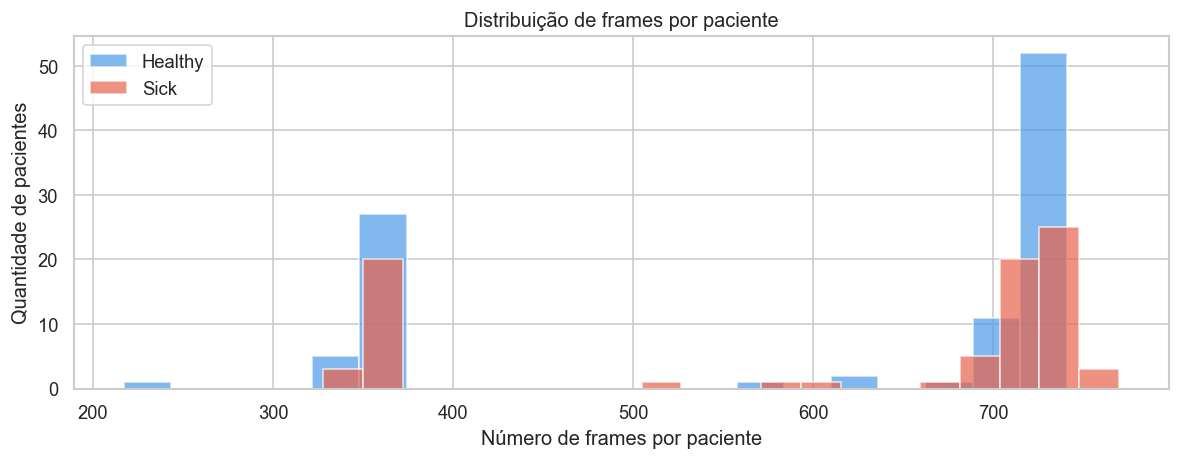

         count   mean    std    min    25%    50%    75%    max
class                                                          
Healthy  100.0  596.2  177.4  217.0  356.8  715.0  728.0  741.0
Sick      80.0  611.6  168.3  328.0  357.8  717.0  732.0  770.0


In [14]:
fig, ax = plt.subplots(figsize=(10, 4))

for cls, color in zip(CLASSES, ['#4C9BE8', '#E8624C']):
    data = df[df['class'] == cls]['n_frames']
    ax.hist(data, bins=20, alpha=0.7, label=cls, color=color, edgecolor='white')

ax.set_xlabel('Número de frames por paciente')
ax.set_ylabel('Quantidade de pacientes')
ax.set_title('Distribuição de frames por paciente')
ax.legend()
plt.tight_layout()
plt.savefig('../results/frames_per_patient.png', bbox_inches='tight')
plt.show()

print(df.groupby('class')['n_frames'].describe().round(1))

## 5. Amostras visuais

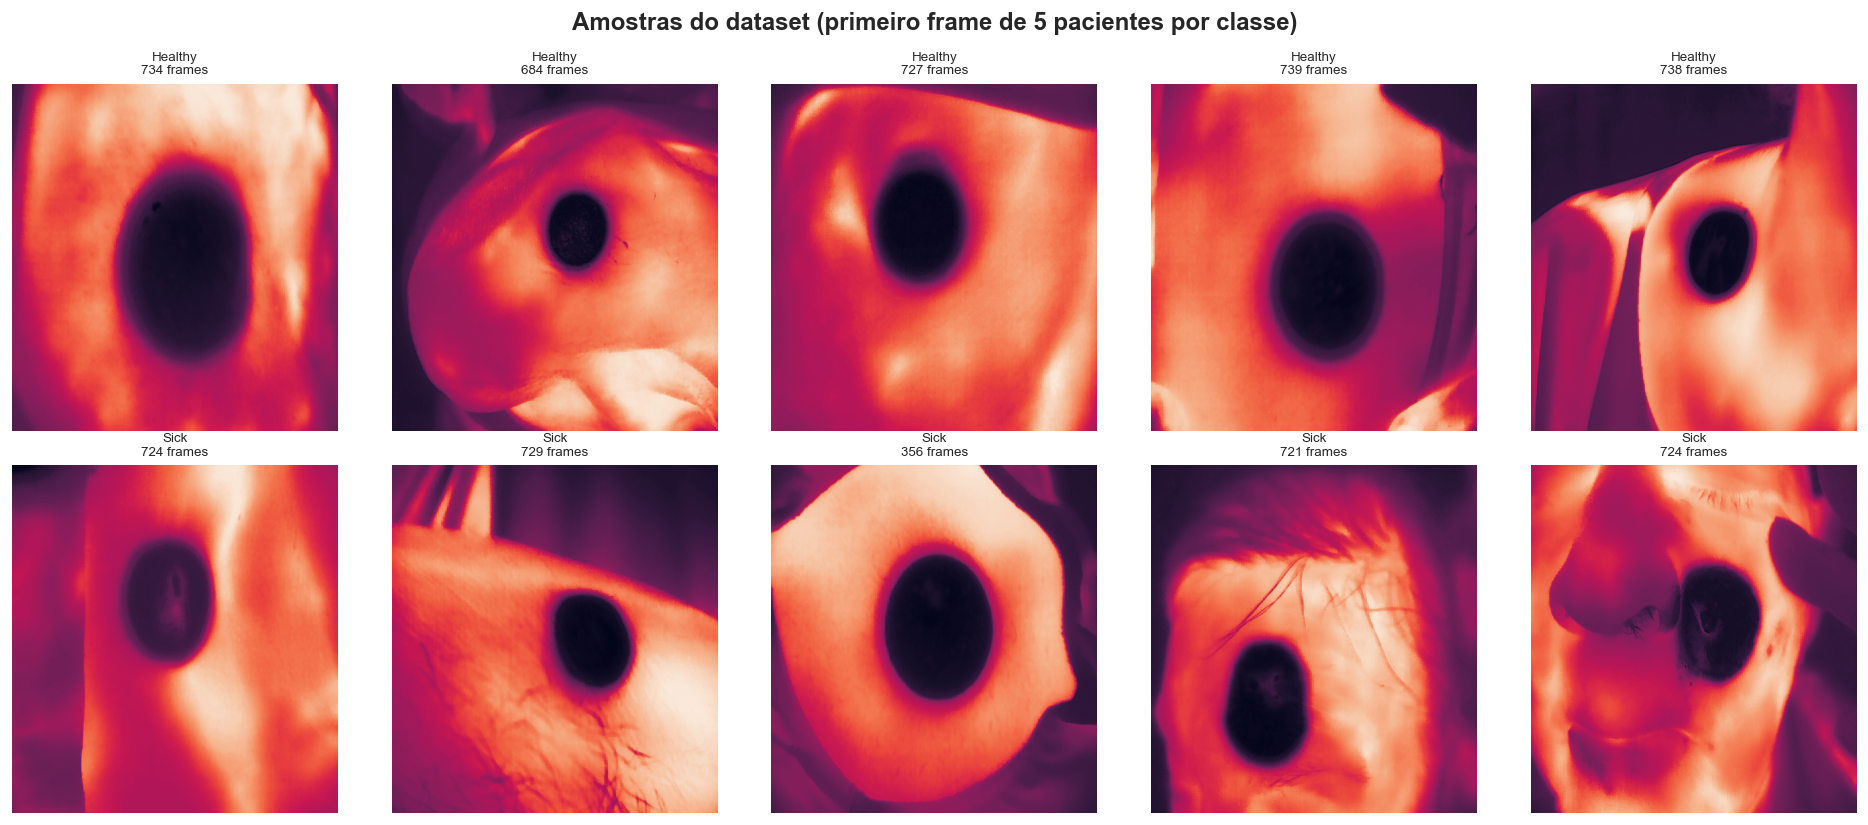

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for row, cls in enumerate(CLASSES):
    patients = df[df['class'] == cls].sample(5, random_state=42)
    for col, (_, patient) in enumerate(patients.iterrows()):
        img = np.array(Image.open(patient['first_frame']))
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{cls}\n{patient["n_frames"]} frames', fontsize=8)
        axes[row, col].axis('off')

plt.suptitle('Amostras do dataset (primeiro frame de 5 pacientes por classe)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/sample_images.png', bbox_inches='tight')
plt.show()

## 6. Propriedades das imagens

In [16]:
sample_paths = pd.concat([
    df[df['class'] == cls].sample(5, random_state=42) for cls in CLASSES
]).reset_index(drop=True)

shapes = []
for _, row in sample_paths.iterrows():
    img = np.array(Image.open(row['first_frame']))
    shapes.append({'class': row['class'], 'height': img.shape[0], 'width': img.shape[1],
                   'channels': img.shape[2] if img.ndim == 3 else 1,
                   'dtype': str(img.dtype)})

shapes_df = pd.DataFrame(shapes)
print('Dimensões e tipo das imagens amostradas:')
print(shapes_df.to_string(index=False))

# Verificar estrutura real dos canais
img = np.array(Image.open(df.iloc[0]['first_frame']))
print(f'\nShape raw da imagem: {img.shape}')
if img.ndim == 3:
    channels_identical = np.array_equal(img[:,:,0], img[:,:,1]) and np.array_equal(img[:,:,0], img[:,:,2])
    print(f'Canais RGB idênticos (grayscale replicado): {channels_identical}')
else:
    print('Imagem é grayscale puro (1 canal — 2D array)')

Dimensões e tipo das imagens amostradas:
  class  height  width  channels dtype
Healthy     512    480         1 uint8
Healthy     512    480         1 uint8
Healthy     512    480         1 uint8
Healthy     512    480         1 uint8
Healthy     512    480         1 uint8
   Sick     512    480         1 uint8
   Sick     512    480         1 uint8
   Sick     512    480         1 uint8
   Sick     512    480         1 uint8
   Sick     512    480         1 uint8

Shape raw da imagem: (512, 480)
Imagem é grayscale puro (1 canal — 2D array)


## 7. Estatísticas de pixel

In [17]:
print('Calculando estatísticas de pixel (1 frame por paciente)...')

stats = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    img = np.array(Image.open(row['first_frame'])).astype(np.float32)
    gray = img if img.ndim == 2 else img[:, :, 0]
    stats.append({
        'class': row['class'],
        'mean': gray.mean(),
        'std': gray.std(),
        'min': gray.min(),
        'max': gray.max(),
    })

stats_df = pd.DataFrame(stats)
print()
print(stats_df.groupby('class')[['mean', 'std', 'min', 'max']].mean().round(2))

Calculando estatísticas de pixel (1 frame por paciente)...


100%|██████████| 180/180 [00:00<00:00, 380.42it/s]


               mean        std    min         max
class                                            
Healthy  124.989998  49.150002  30.15  223.639999
Sick     124.000000  50.330002  29.58  224.199997


## 8. Distribuição de intensidade de pixel por classe

/var/folders/l_/6cdjgq2916n__p7hpg6gph8m0000gn/T/ipykernel_22781/2655131745.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stats_df, x='class', y='mean', palette=['#4C9BE8', '#E8624C'], ax=axes[1])


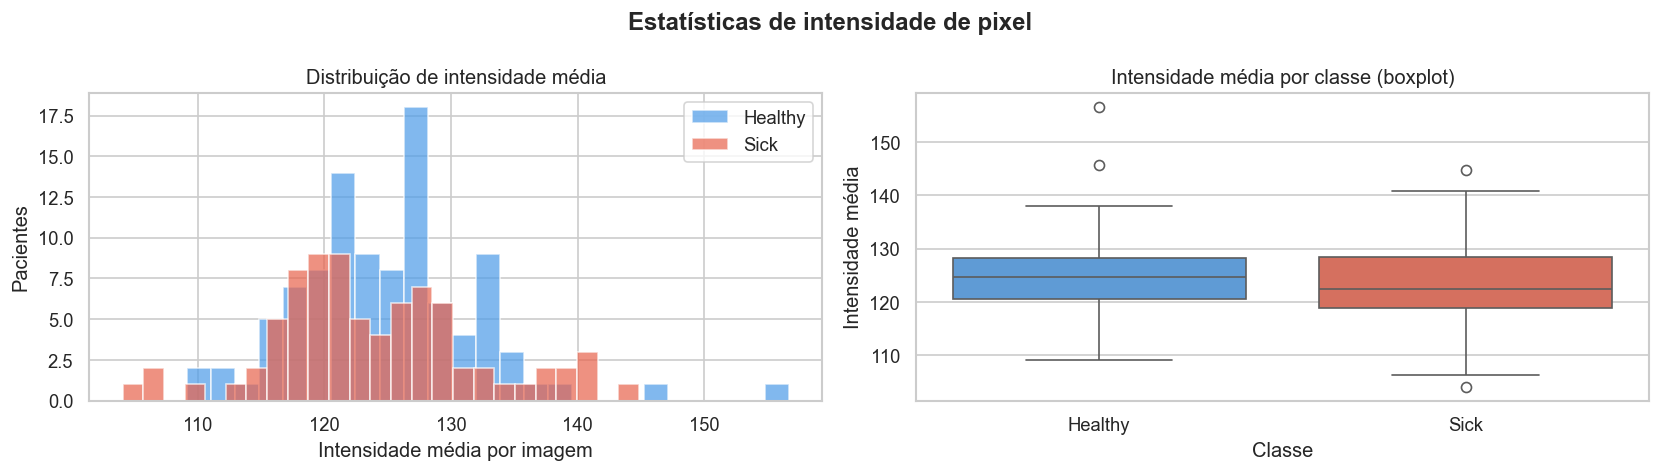

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de intensidade médias
for cls, color in zip(CLASSES, ['#4C9BE8', '#E8624C']):
    data = stats_df[stats_df['class'] == cls]['mean']
    axes[0].hist(data, bins=25, alpha=0.7, label=cls, color=color, edgecolor='white')
axes[0].set_xlabel('Intensidade média por imagem')
axes[0].set_ylabel('Pacientes')
axes[0].set_title('Distribuição de intensidade média')
axes[0].legend()

# Boxplot de intensidade média por classe
sns.boxplot(data=stats_df, x='class', y='mean', palette=['#4C9BE8', '#E8624C'], ax=axes[1])
axes[1].set_title('Intensidade média por classe (boxplot)')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Intensidade média')

plt.suptitle('Estatísticas de intensidade de pixel', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/pixel_statistics.png', bbox_inches='tight')
plt.show()

## 9. Sequência temporal de um paciente

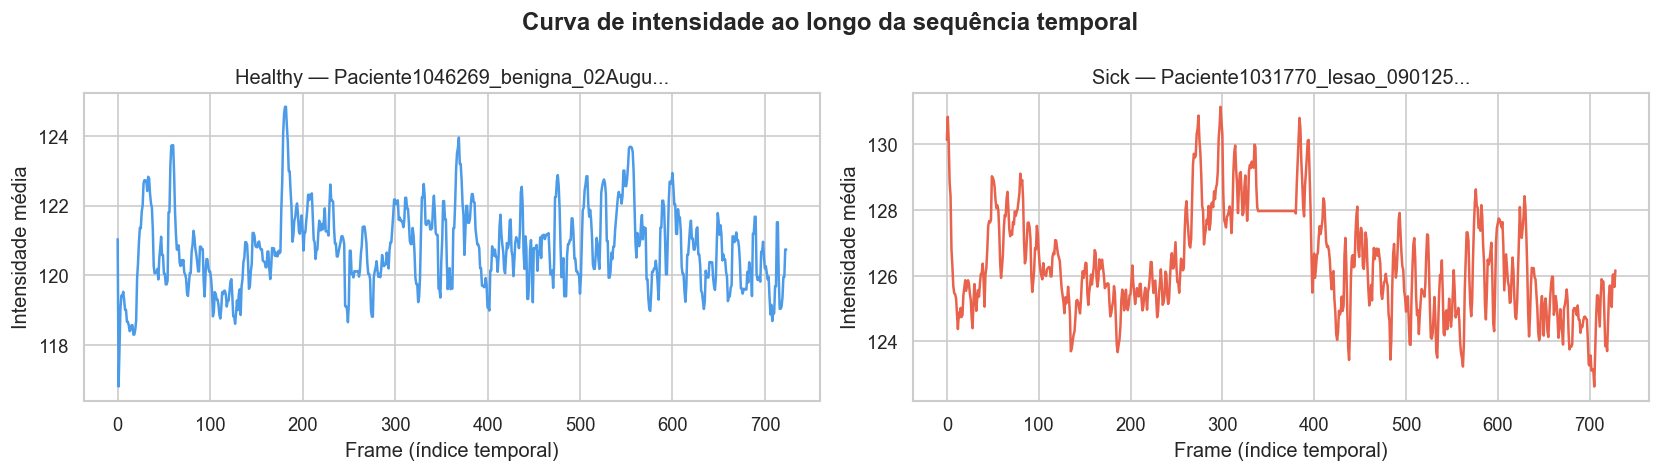

In [19]:
# Visualiza a evolução da intensidade média ao longo da sequência de frames de um paciente
# (aclimatação → resfriamento → recuperação)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, cls in zip(axes, CLASSES):
    patient = df[df['class'] == cls].iloc[0]
    patient_dir = DATASET_ROOT / cls / patient['patient_id']
    frames = sorted(patient_dir.glob('*.png'))

    means = [np.array(Image.open(f)).mean() for f in frames]
    ax.plot(means, color='#4C9BE8' if cls == 'Healthy' else '#E8624C', linewidth=1.5)
    ax.set_xlabel('Frame (índice temporal)')
    ax.set_ylabel('Intensidade média')
    ax.set_title(f'{cls} — {patient["patient_id"][:30]}...')

plt.suptitle('Curva de intensidade ao longo da sequência temporal', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/temporal_sequence.png', bbox_inches='tight')
plt.show()

## 10. Resumo e observações

In [20]:
total_patients = len(df)
total_frames = df['n_frames'].sum()
healthy_patients = len(df[df['class'] == 'Healthy'])
sick_patients = len(df[df['class'] == 'Sick'])

print('=' * 50)
print('RESUMO DO DATASET TR_heatSkin')
print('=' * 50)
print(f'Total de pacientes : {total_patients}')
print(f'  Healthy          : {healthy_patients} ({100*healthy_patients/total_patients:.1f}%)')
print(f'  Sick             : {sick_patients} ({100*sick_patients/total_patients:.1f}%)')
print(f'Total de frames    : {total_frames:,}')
print(f'Dimensão das imagens: 480 x 512 px (RGB grayscale replicado)')
print(f'Frames por paciente: min={df["n_frames"].min()} | max={df["n_frames"].max()} | média={df["n_frames"].mean():.1f}')
print()
print('OBSERVAÇÕES:')
print('- Dataset incompleto: 15 pacientes de Ceratose serão adicionados pelo orientador')
print('- Split deve ser feito por paciente para evitar data leakage entre frames')
print('- Canais RGB são idênticos (escala de cinza replicada nos 3 canais)')
print('- Pré-processamento manual já aplicado: primeiros frames removidos, ROI recortada')
print('=' * 50)

RESUMO DO DATASET TR_heatSkin
Total de pacientes : 180
  Healthy          : 100 (55.6%)
  Sick             : 80 (44.4%)
Total de frames    : 108,548
Dimensão das imagens: 480 x 512 px (RGB grayscale replicado)
Frames por paciente: min=217 | max=770 | média=603.0

OBSERVAÇÕES:
- Dataset incompleto: 15 pacientes de Ceratose serão adicionados pelo orientador
- Split deve ser feito por paciente para evitar data leakage entre frames
- Canais RGB são idênticos (escala de cinza replicada nos 3 canais)
- Pré-processamento manual já aplicado: primeiros frames removidos, ROI recortada
